# REGRESION LINEAL MULTIPLE PARA SEGURO MEDICO APLICANDO DATOS CATEGORICOS
## DATASET [kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [ ]:
!ls /kaggle/input/insurance

insurance.csv


In [ ]:
PATH_CSV = path + "/insurance.csv"

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [ ]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [ ]:
df = pd.read_csv(PATH_CSV)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


 # PASO 3 : EDA

## VERIFICAMOS SI HAY VALORES NULOS

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [ ]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['sex', 'smoker', 'region'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [ ]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
sex
male      676
female    662
Name: count, dtype: int64
**************************************************
smoker
no     1064
yes     274
Name: count, dtype: int64
**************************************************
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## 4.3 DIVIDO LAS VARIABLES POR TIOP DE CODIFICACIÓN(LABEL Y ONE HOT ENCODING)

In [ ]:
ordinal_cols = ['sex','smoker']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(f'ordinal cols : {ordinal_cols}')
print(f'onehot cols : {onehot_cols}')

ordinal cols : ['sex', 'smoker']
onehot cols : ['region']


## 4.4 CODIFICAMOS USANDO LOS MODULOS COMPOSE Y PREPROCESSING DE SKLEARN

In [ ]:
import sklearn.compose
import sklearn.preprocessing

In [ ]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['sex', 'smoker']),
                                ('onehotencoder', OneHotEncoder(), ['region'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [ ]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__sex,ordinalencoder__smoker,onehotencoder__region_northeast,onehotencoder__region_northwest,onehotencoder__region_southeast,onehotencoder__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [ ]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age,bmi,children,charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [ ]:
data_transformed_df.dtypes

,0
sex,float64
smoker,float64
region_northeast,float64
region_northwest,float64
region_southeast,float64
region_southwest,float64
age,float64
bmi,float64
children,float64
charges,float64


# 5 - CORRELACIONES

In [ ]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['charges']
corr_charges.sort_values(ascending=False)

,charges
charges,1.000000
smoker,0.787251
age,0.299008
bmi,0.198341
region_southeast,0.073982
children,0.067998
sex,0.057292
region_northeast,0.006349
region_northwest,-0.039905
region_southwest,-0.043210


<Axes: >

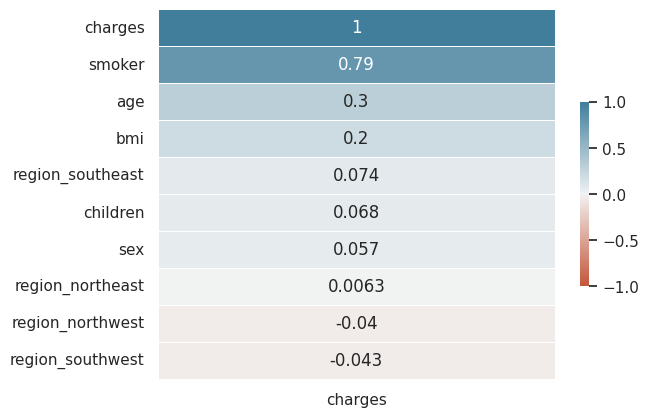

In [ ]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [ ]:
cols = corr_charges.index.tolist()
cols.remove('charges')
cols

['sex',
 'smoker',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'age',
 'bmi',
 'children']

# 6 - ENTRENAMIENTO DEL MODELO

In [ ]:
X_cols = ['smoker','age','bmi']
#X_cols = cols
y_col = ['charges']

In [ ]:
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

X = data_transformed_df[X_cols].values
y = data_transformed_df[y_col].values.reshape(-1,1)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.fit_transform(y_test)

#creamos el modelo
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


#erro cuadratico medio
mse = metrics.mean_squared_error(y_test,y_pred)
#R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.2217
El coeficiente de determinación(R2) es de 0.7783


# GRAFICAMOS VALORES REALES CON VALORES PREDECIDOS

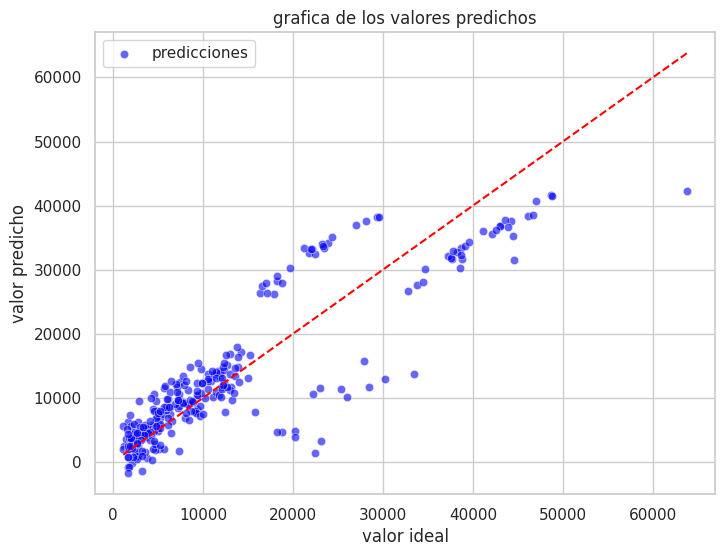

In [ ]:
y_test_inv = sc_y.inverse_transform(y_test)
y_pred_inv = sc_y.inverse_transform(y_pred)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_inv.flatten(),y=y_pred_inv.flatten(),alpha=0.6,color='blue',label='predicciones')
plt.plot([min(y_test_inv),max(y_test_inv)],[min(y_test_inv),max(y_test_inv)],color='red',linestyle='--')

plt.xlabel("valor ideal")
plt.ylabel("valor predicho")
plt.title("grafica de los valores predichos")
plt.legend()
plt.show()

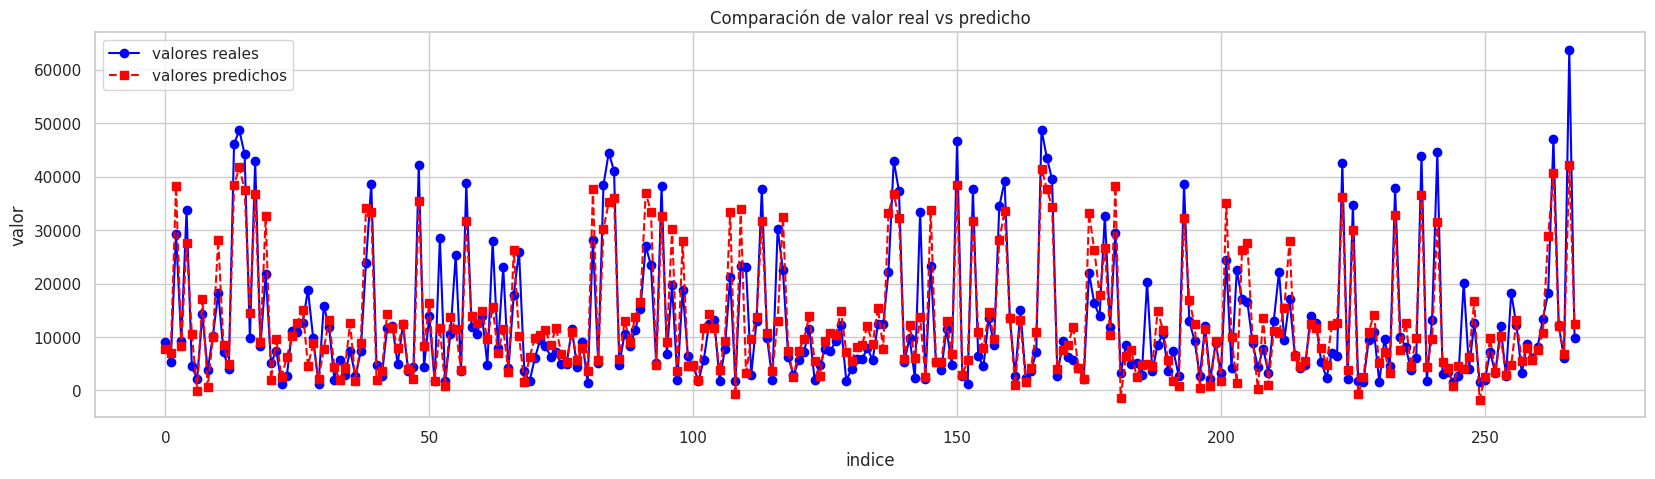

In [ ]:
y_test_inv = sc_y.inverse_transform(y_test)
y_pred_inv = sc_y.inverse_transform(y_pred)


plt.figure(figsize=(20,5))
plt.plot(y_test_inv.flatten(),label='valores reales',marker='o',linestyle='-',color='blue')
plt.plot(y_pred_inv.flatten(),label='valores predichos',marker='s',linestyle='--',color='red')


plt.xlabel("indice")
plt.ylabel("valor")
plt.title("Comparación de valor real vs predicho")
plt.legend()
plt.grid(True)
plt.show()